# Comparing the results of multiple 
This document 

## Setup

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [14]:
from os import listdir
from os.path import isfile

Importing the collected data

In [3]:
from google.colab import files
uploaded = files.upload()
%ls

Saving binance-coin5m.csv to binance-coin5m.csv
Saving binance-coindaily.csv to binance-coindaily.csv
Saving binance-coinhourly.csv to binance-coinhourly.csv
Saving bitcoin-cash5m.csv to bitcoin-cash5m.csv
Saving bitcoin-cashdaily.csv to bitcoin-cashdaily.csv
Saving bitcoin-cashhourly.csv to bitcoin-cashhourly.csv
Saving bitcoin5m.csv to bitcoin5m.csv
Saving bitcoindaily.csv to bitcoindaily.csv
Saving bitcoinhourly.csv to bitcoinhourly.csv
Saving cardano5m.csv to cardano5m.csv
Saving cardanodaily.csv to cardanodaily.csv
Saving cardanohourly.csv to cardanohourly.csv
Saving chainlink5m.csv to chainlink5m.csv
Saving chainlinkdaily.csv to chainlinkdaily.csv
Saving chainlinkhourly.csv to chainlinkhourly.csv
Saving ethereum5m.csv to ethereum5m.csv
Saving ethereumdaily.csv to ethereumdaily.csv
Saving ethereumhourly.csv to ethereumhourly.csv
Saving litecoin5m.csv to litecoin5m.csv
Saving litecoindaily.csv to litecoindaily.csv
Saving litecoinhourly.csv to litecoinhourly.csv
Saving polkadot-new5

In [15]:
def plot_time_series(predicted, true, n_training, filename):
  """
  Plot the time series
  """
  plt.figure(figsize=(16,10)) #plotting
  plt.axvline(x=n_training, color="#ffd166", linestyle='-') #size of the training set

  plt.plot(predicted, label='Predicted Price', color="#118ab2") #predicted plot
  plt.plot(true, label='True Price', color="#06d6a0") #actual plot

  plt.title('Time-Series Prediction', fontsize=16)
  plt.xlabel('Time', fontsize=14)
  plt.ylabel('Price', fontsize=14)

  plt.xlim(0)
  plt.legend()
  plt.savefig(filename) 


## LSTM Model


### Model Definition

In [16]:
class LSTMCustom(nn.Module):
    def __init__(self, num_classes, input_size, hidden_size, num_layers, seq_length):
        super(LSTMCustom, self).__init__()
        self.num_classes = num_classes #number of classes
        self.num_layers = num_layers #number of layers
        self.input_size = input_size #input size
        self.hidden_size = hidden_size #hidden state
        self.seq_length = seq_length #sequence length

        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                          num_layers=num_layers, batch_first=True) #lstm
        self.fc_1 =  nn.Linear(hidden_size, 128) #fully connected 1
        self.fc = nn.Linear(128, num_classes) #fully connected last layer

        self.relu = nn.ReLU()
    
    def forward(self,x):
        h_0 = Variable(torch.zeros(self.num_layers, x.size(0), self.hidden_size)) #hidden state
        c_0 = Variable(torch.zeros(self.num_layers, x.size(0), self.hidden_size)) #internal state
        # Propagate input through LSTM
        output, (hn, cn) = self.lstm(x, (h_0, c_0)) #lstm with input, hidden, and internal state
        hn = hn.view(-1, self.hidden_size) #reshaping the data for Dense layer next
        out = self.relu(hn)
        out = self.fc_1(out) #first Dense
        out = self.relu(out) #relu
        out = self.fc(out) #Final Output
        return out

Model Parameters

In [17]:
num_epochs = 2000 #1000 epochs
learning_rate = 0.001 #0.001 lr

input_size = 22 #number of features
hidden_size = 40 #number of features in hidden state
num_layers = 1 #number of stacked lstm layers

num_classes = 1 #number of output classes 

In [18]:
criterion = torch.nn.MSELoss()  # mean-squared error for regression

### Training Each Crypto

In [19]:
mm = MinMaxScaler()
ss = StandardScaler()

In [20]:
def train_test_split_tensor(x, y):
  """
  Custom train/test splitting
  TODO: maybe shorten code by using sklearn.preprocessing.train_test_split
  """
  cutoff = round(x.shape[0] * 0.7)

  # split into train and test
  x_train = x[:cutoff, :]
  x_test = x[cutoff:,:]
  y_train = y[:cutoff, :]
  y_test = y[cutoff:, :]

  # convert to tensor
  x_train = Variable(torch.Tensor(x_train))
  x_test = Variable(torch.Tensor(x_test))
  y_train = Variable(torch.Tensor(y_train))
  y_test = Variable(torch.Tensor(y_test)) 
  
  return x_train, x_test, y_train, y_test, cutoff

In [21]:
def process_data(df):

  # shift the prices
  df2 = df.copy(deep=True)
  df['priceUsd'] = df.priceUsd.shift(1)
  df = df.iloc[1:-1]
  df2 = df2.iloc[1:-1]

  # split into x and y
  x = df.iloc[:, 0:-1]
  y = df2.iloc[:, 0:1]

  # transform the data
  x_ss = ss.fit_transform(x)
  y_mm = mm.fit_transform(y) 

  # get train and test split and convert to tensors
  x_train, x_test, y_train, y_test, cutoff = train_test_split_tensor(x_ss, y_mm)

  # reshape tensors 
  x_train = torch.reshape(x_train, (x_train.shape[0], 1, x_train.shape[1]))
  x_test = torch.reshape(x_test, (x_test.shape[0], 1, x_test.shape[1])) 

  return x_train, x_test, y_train, y_test, cutoff

In [22]:
def train(df, lstm):
  """
  Train the lstm
  """
  x_train, x_test, y_train, y_test, cutoff = process_data(df)

  for epoch in range(num_epochs):
    outputs = lstm.forward(x_train) #forward pass
    optimizer.zero_grad() #caluclate the gradient, manually setting to 0
  
    # obtain the loss function
    loss = criterion(outputs, y_train)
  
    loss.backward() #calculates the loss of the loss function
  
    optimizer.step() #improve from loss, i.e backprop
    if epoch % 100 == 0:
      print("Epoch: %d, loss: %1.5f" % (epoch, loss.item())) 

  return lstm, cutoff

In [12]:
# dir_path = "data/"
# file_list = [f for f in listdir(dir_path) if isfile(join(dir_path, f))]
file_list = [f for f in listdir() if isfile(f)]
print(file_list)

['uniswap5m.csv', 'ripple5m.csv', 'rippledaily.csv', 'cardano5m.csv', 'bitcoinhourly.csv', 'wrapped-bitcoin5m.csv', 'binance-coinhourly.csv', 'bitcoin5m.csv', 'polkadot-newdaily.csv', 'cardanohourly.csv', 'uniswaphourly.csv', 'chainlinkhourly.csv', 'uniswapdaily.csv', 'wrapped-bitcoinhourly.csv', 'polkadot-new5m.csv', 'ripplehourly.csv', 'polkadot-newhourly.csv', 'stellardaily.csv', 'binance-coindaily.csv', 'litecoinhourly.csv', 'chainlinkdaily.csv', 'litecoindaily.csv', 'wrapped-bitcoindaily.csv', 'bitcoin-cashdaily.csv', 'ethereumhourly.csv', 'stellarhourly.csv', 'cardanodaily.csv', 'binance-coin5m.csv', 'bitcoin-cashhourly.csv', 'bitcoin-cash5m.csv', 'ethereum5m.csv', 'chainlink5m.csv', 'ethereumdaily.csv', 'litecoin5m.csv', 'stellar5m.csv', 'bitcoindaily.csv']


Epoch: 0, loss: 0.05143
Epoch: 100, loss: 0.00270
Epoch: 200, loss: 0.00012
Epoch: 300, loss: 0.00005
Epoch: 400, loss: 0.00004
Epoch: 500, loss: 0.00003
Epoch: 600, loss: 0.00003
Epoch: 700, loss: 0.00003
Epoch: 800, loss: 0.00003
Epoch: 900, loss: 0.00003
Epoch: 1000, loss: 0.00003
Epoch: 1100, loss: 0.00003
Epoch: 1200, loss: 0.00003
Epoch: 1300, loss: 0.00003
Epoch: 1400, loss: 0.00002
Epoch: 1500, loss: 0.00002
Epoch: 1600, loss: 0.00002
Epoch: 1700, loss: 0.00002
Epoch: 1800, loss: 0.00002
Epoch: 1900, loss: 0.00002


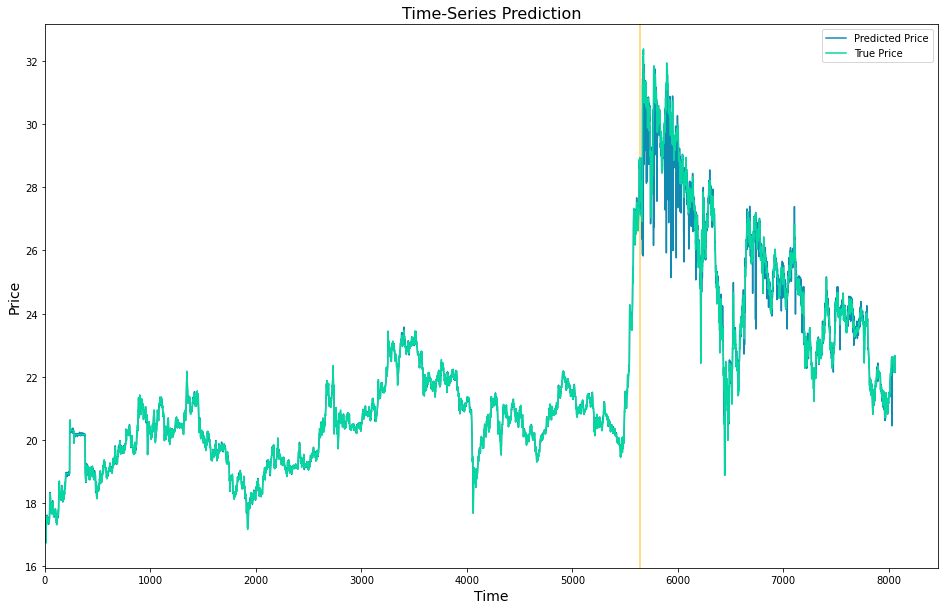

Epoch: 0, loss: 0.14138
Epoch: 100, loss: 0.00133
Epoch: 200, loss: 0.00019
Epoch: 300, loss: 0.00010
Epoch: 400, loss: 0.00007
Epoch: 500, loss: 0.00006
Epoch: 600, loss: 0.00005
Epoch: 700, loss: 0.00005
Epoch: 800, loss: 0.00004
Epoch: 900, loss: 0.00004
Epoch: 1000, loss: 0.00004
Epoch: 1100, loss: 0.00004
Epoch: 1200, loss: 0.00003
Epoch: 1300, loss: 0.00003
Epoch: 1400, loss: 0.00003
Epoch: 1500, loss: 0.00003
Epoch: 1600, loss: 0.00003
Epoch: 1700, loss: 0.00003
Epoch: 1800, loss: 0.00003
Epoch: 1900, loss: 0.00003


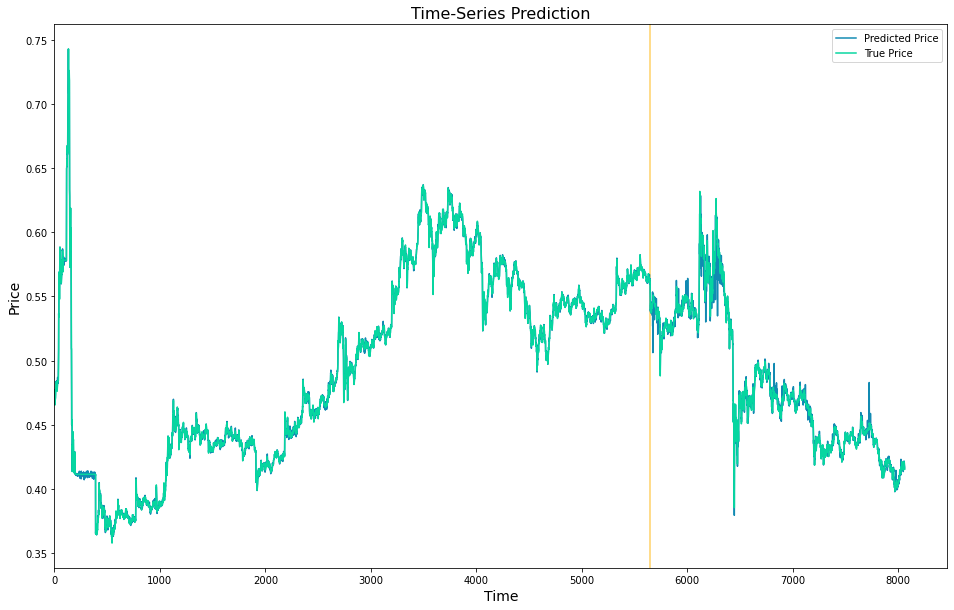

Epoch: 0, loss: 0.23231
Epoch: 100, loss: 0.00367
Epoch: 200, loss: 0.00067
Epoch: 300, loss: 0.00020
Epoch: 400, loss: 0.00011
Epoch: 500, loss: 0.00008
Epoch: 600, loss: 0.00006
Epoch: 700, loss: 0.00004
Epoch: 800, loss: 0.00004
Epoch: 900, loss: 0.00003
Epoch: 1000, loss: 0.00003
Epoch: 1100, loss: 0.00002
Epoch: 1200, loss: 0.00002
Epoch: 1300, loss: 0.00002
Epoch: 1400, loss: 0.00002
Epoch: 1500, loss: 0.00002
Epoch: 1600, loss: 0.00002
Epoch: 1700, loss: 0.00001
Epoch: 1800, loss: 0.00001
Epoch: 1900, loss: 0.00001


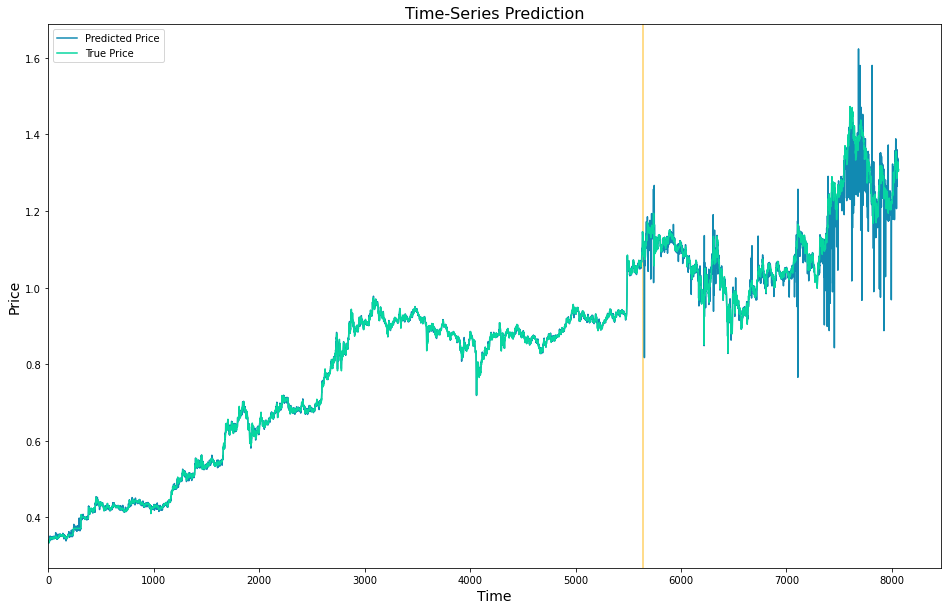

Epoch: 0, loss: 0.31871
Epoch: 100, loss: 0.00211
Epoch: 200, loss: 0.00022
Epoch: 300, loss: 0.00007
Epoch: 400, loss: 0.00003
Epoch: 500, loss: 0.00002
Epoch: 600, loss: 0.00002
Epoch: 700, loss: 0.00001
Epoch: 800, loss: 0.00001
Epoch: 900, loss: 0.00001
Epoch: 1000, loss: 0.00001
Epoch: 1100, loss: 0.00001
Epoch: 1200, loss: 0.00001
Epoch: 1300, loss: 0.00001
Epoch: 1400, loss: 0.00001
Epoch: 1500, loss: 0.00001
Epoch: 1600, loss: 0.00001
Epoch: 1700, loss: 0.00001
Epoch: 1800, loss: 0.00001
Epoch: 1900, loss: 0.00001


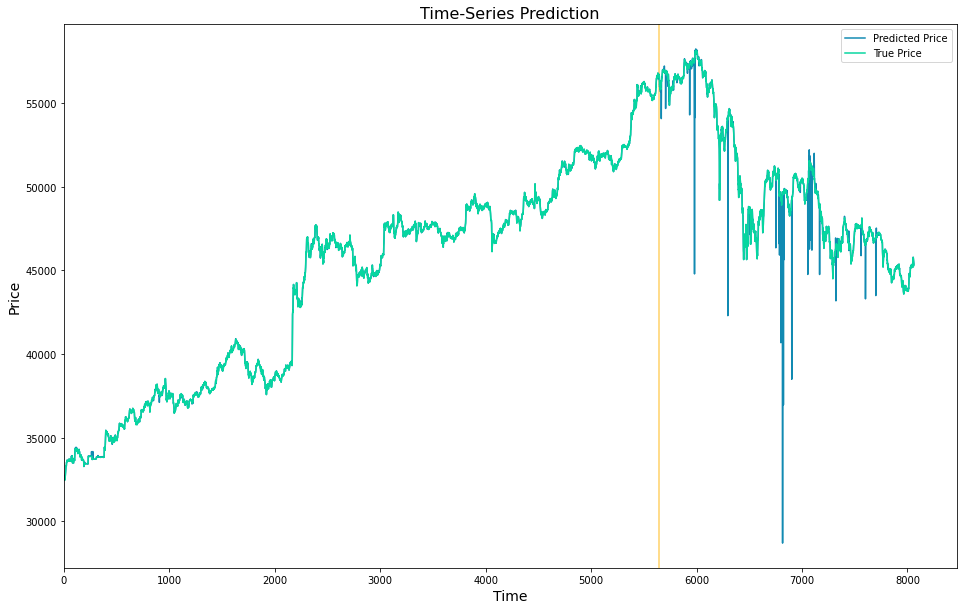

Epoch: 0, loss: 0.28203
Epoch: 100, loss: 0.00528
Epoch: 200, loss: 0.00048
Epoch: 300, loss: 0.00020
Epoch: 400, loss: 0.00012
Epoch: 500, loss: 0.00008
Epoch: 600, loss: 0.00006
Epoch: 700, loss: 0.00005
Epoch: 800, loss: 0.00004
Epoch: 900, loss: 0.00003
Epoch: 1000, loss: 0.00003
Epoch: 1100, loss: 0.00003
Epoch: 1200, loss: 0.00003
Epoch: 1300, loss: 0.00002
Epoch: 1400, loss: 0.00002
Epoch: 1500, loss: 0.00002
Epoch: 1600, loss: 0.00002
Epoch: 1700, loss: 0.00002
Epoch: 1800, loss: 0.00002
Epoch: 1900, loss: 0.00002


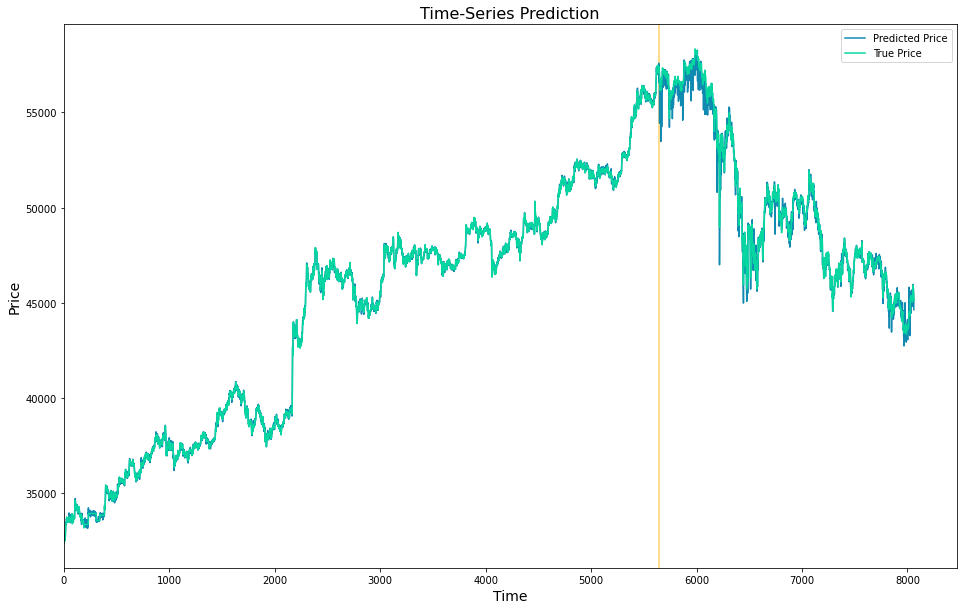

Epoch: 0, loss: 0.12865
Epoch: 100, loss: 0.00158
Epoch: 200, loss: 0.00012
Epoch: 300, loss: 0.00006
Epoch: 400, loss: 0.00005
Epoch: 500, loss: 0.00004
Epoch: 600, loss: 0.00003
Epoch: 700, loss: 0.00003
Epoch: 800, loss: 0.00003
Epoch: 900, loss: 0.00002
Epoch: 1000, loss: 0.00002
Epoch: 1100, loss: 0.00002
Epoch: 1200, loss: 0.00002
Epoch: 1300, loss: 0.00002
Epoch: 1400, loss: 0.00002
Epoch: 1500, loss: 0.00002
Epoch: 1600, loss: 0.00002
Epoch: 1700, loss: 0.00002
Epoch: 1800, loss: 0.00002
Epoch: 1900, loss: 0.00002


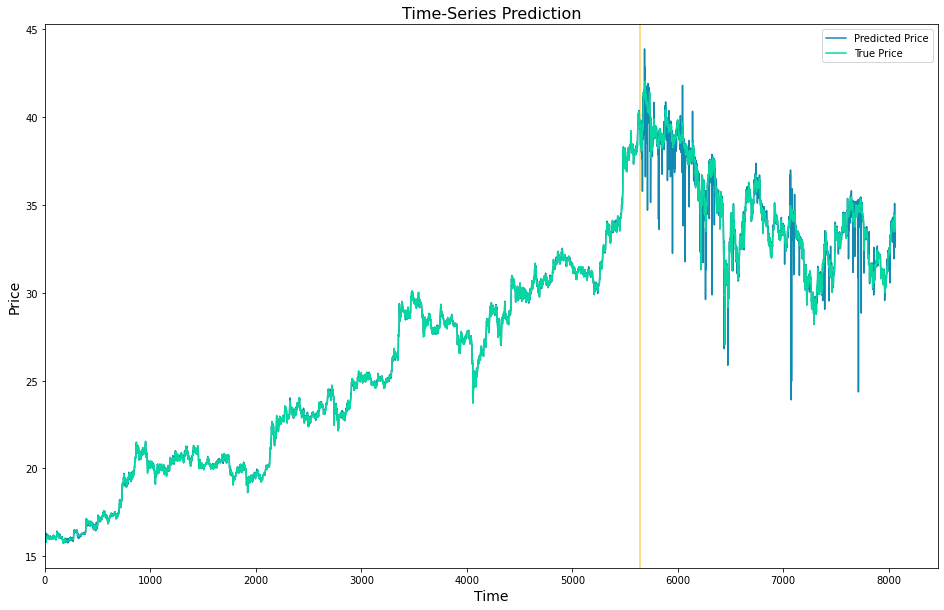

Epoch: 0, loss: 0.09568
Epoch: 100, loss: 0.00144
Epoch: 200, loss: 0.00017
Epoch: 300, loss: 0.00008
Epoch: 400, loss: 0.00005
Epoch: 500, loss: 0.00004
Epoch: 600, loss: 0.00003
Epoch: 700, loss: 0.00002
Epoch: 800, loss: 0.00002
Epoch: 900, loss: 0.00002
Epoch: 1000, loss: 0.00001
Epoch: 1100, loss: 0.00001
Epoch: 1200, loss: 0.00001
Epoch: 1300, loss: 0.00001
Epoch: 1400, loss: 0.00001
Epoch: 1500, loss: 0.00001
Epoch: 1600, loss: 0.00001
Epoch: 1700, loss: 0.00001
Epoch: 1800, loss: 0.00001
Epoch: 1900, loss: 0.00001


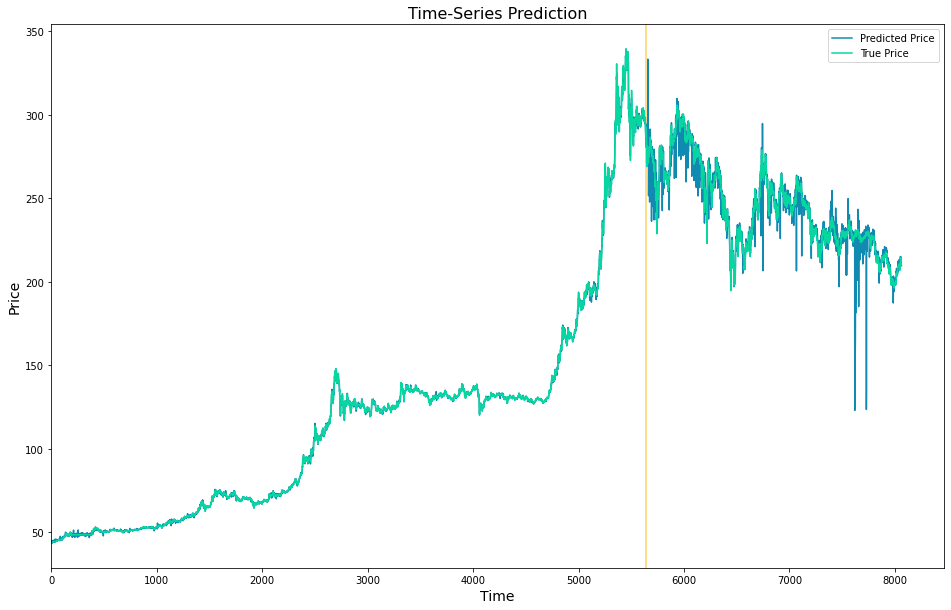

Epoch: 0, loss: 0.25015
Epoch: 100, loss: 0.00213
Epoch: 200, loss: 0.00025
Epoch: 300, loss: 0.00013
Epoch: 400, loss: 0.00009
Epoch: 500, loss: 0.00007
Epoch: 600, loss: 0.00006
Epoch: 700, loss: 0.00005
Epoch: 800, loss: 0.00005
Epoch: 900, loss: 0.00005
Epoch: 1000, loss: 0.00004
Epoch: 1100, loss: 0.00004
Epoch: 1200, loss: 0.00004
Epoch: 1300, loss: 0.00004
Epoch: 1400, loss: 0.00004
Epoch: 1500, loss: 0.00004
Epoch: 1600, loss: 0.00004
Epoch: 1700, loss: 0.00003
Epoch: 1800, loss: 0.00003
Epoch: 1900, loss: 0.00003


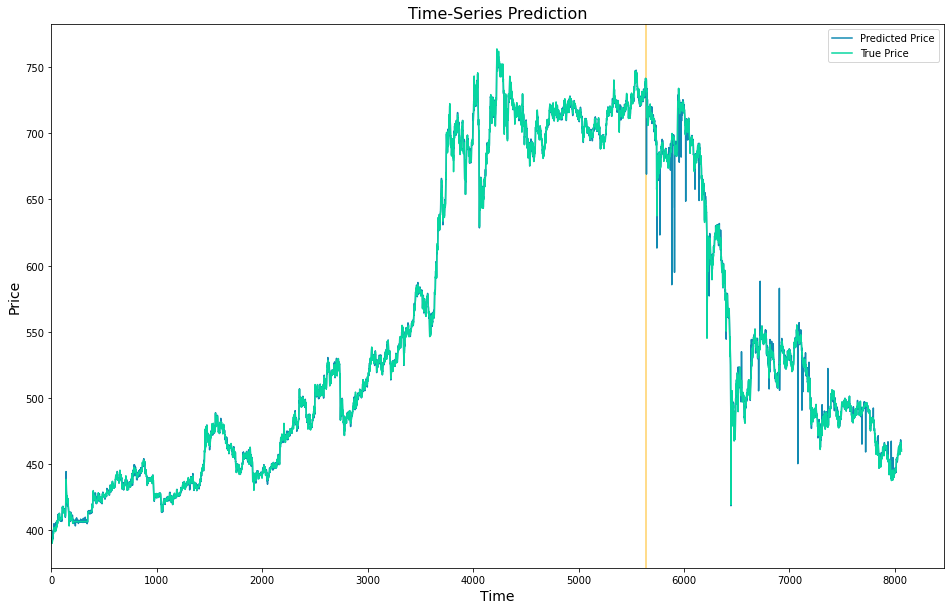

Epoch: 0, loss: 0.27360
Epoch: 100, loss: 0.00312
Epoch: 200, loss: 0.00039
Epoch: 300, loss: 0.00020
Epoch: 400, loss: 0.00014
Epoch: 500, loss: 0.00010
Epoch: 600, loss: 0.00008
Epoch: 700, loss: 0.00007
Epoch: 800, loss: 0.00006
Epoch: 900, loss: 0.00005
Epoch: 1000, loss: 0.00004
Epoch: 1100, loss: 0.00004
Epoch: 1200, loss: 0.00004
Epoch: 1300, loss: 0.00004
Epoch: 1400, loss: 0.00003
Epoch: 1500, loss: 0.00003
Epoch: 1600, loss: 0.00003
Epoch: 1700, loss: 0.00003
Epoch: 1800, loss: 0.00003
Epoch: 1900, loss: 0.00003


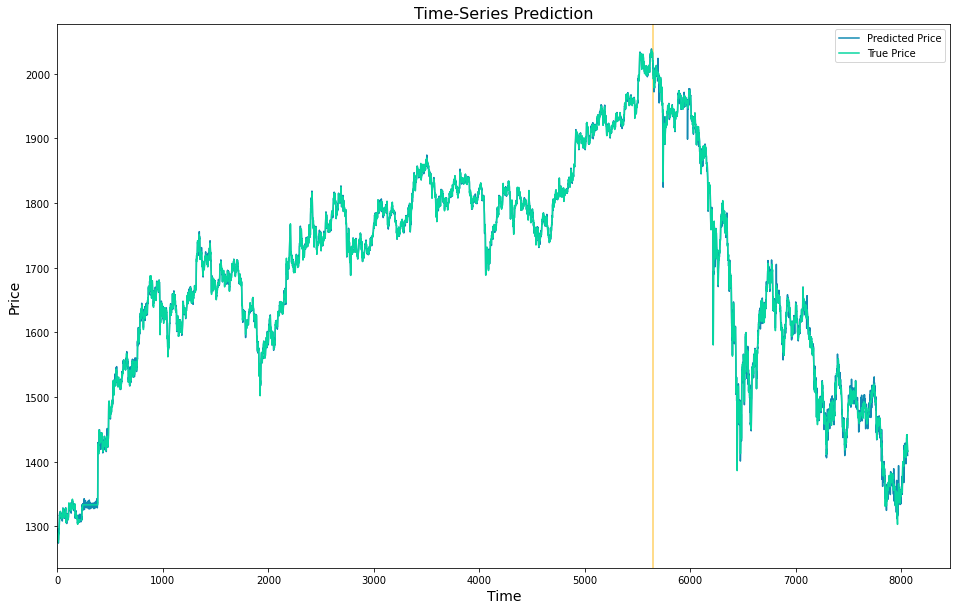

Epoch: 0, loss: 0.20512
Epoch: 100, loss: 0.00171
Epoch: 200, loss: 0.00017
Epoch: 300, loss: 0.00009
Epoch: 400, loss: 0.00007
Epoch: 500, loss: 0.00006
Epoch: 600, loss: 0.00005
Epoch: 700, loss: 0.00005
Epoch: 800, loss: 0.00005
Epoch: 900, loss: 0.00005
Epoch: 1000, loss: 0.00005
Epoch: 1100, loss: 0.00005
Epoch: 1200, loss: 0.00005
Epoch: 1300, loss: 0.00004
Epoch: 1400, loss: 0.00004
Epoch: 1500, loss: 0.00004
Epoch: 1600, loss: 0.00004
Epoch: 1700, loss: 0.00004
Epoch: 1800, loss: 0.00004
Epoch: 1900, loss: 0.00004


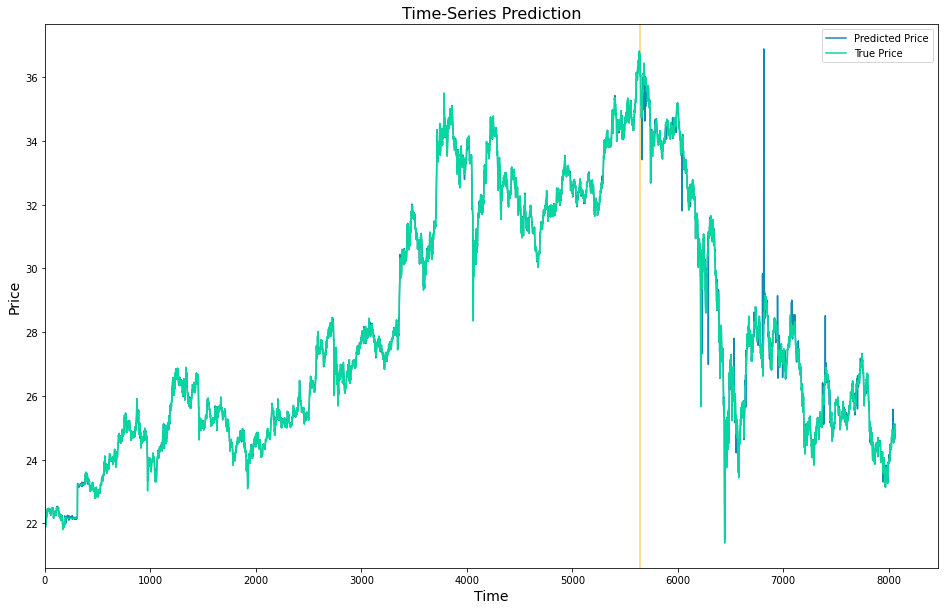

Epoch: 0, loss: 0.27934
Epoch: 100, loss: 0.00294
Epoch: 200, loss: 0.00044
Epoch: 300, loss: 0.00020
Epoch: 400, loss: 0.00013
Epoch: 500, loss: 0.00010
Epoch: 600, loss: 0.00008
Epoch: 700, loss: 0.00007
Epoch: 800, loss: 0.00006
Epoch: 900, loss: 0.00006
Epoch: 1000, loss: 0.00005
Epoch: 1100, loss: 0.00005
Epoch: 1200, loss: 0.00005
Epoch: 1300, loss: 0.00004
Epoch: 1400, loss: 0.00004
Epoch: 1500, loss: 0.00004
Epoch: 1600, loss: 0.00004
Epoch: 1700, loss: 0.00004
Epoch: 1800, loss: 0.00004
Epoch: 1900, loss: 0.00004


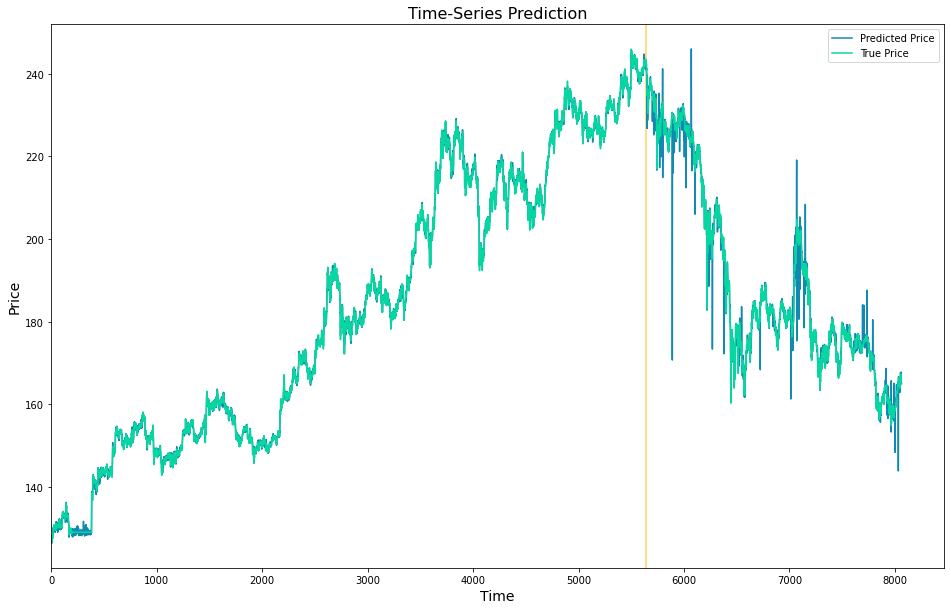

Epoch: 0, loss: 0.20369
Epoch: 100, loss: 0.00195
Epoch: 200, loss: 0.00025
Epoch: 300, loss: 0.00012
Epoch: 400, loss: 0.00008
Epoch: 500, loss: 0.00006
Epoch: 600, loss: 0.00005
Epoch: 700, loss: 0.00005
Epoch: 800, loss: 0.00005
Epoch: 900, loss: 0.00004
Epoch: 1000, loss: 0.00004
Epoch: 1100, loss: 0.00004
Epoch: 1200, loss: 0.00004
Epoch: 1300, loss: 0.00004
Epoch: 1400, loss: 0.00004
Epoch: 1500, loss: 0.00004
Epoch: 1600, loss: 0.00003
Epoch: 1700, loss: 0.00003
Epoch: 1800, loss: 0.00003
Epoch: 1900, loss: 0.00003


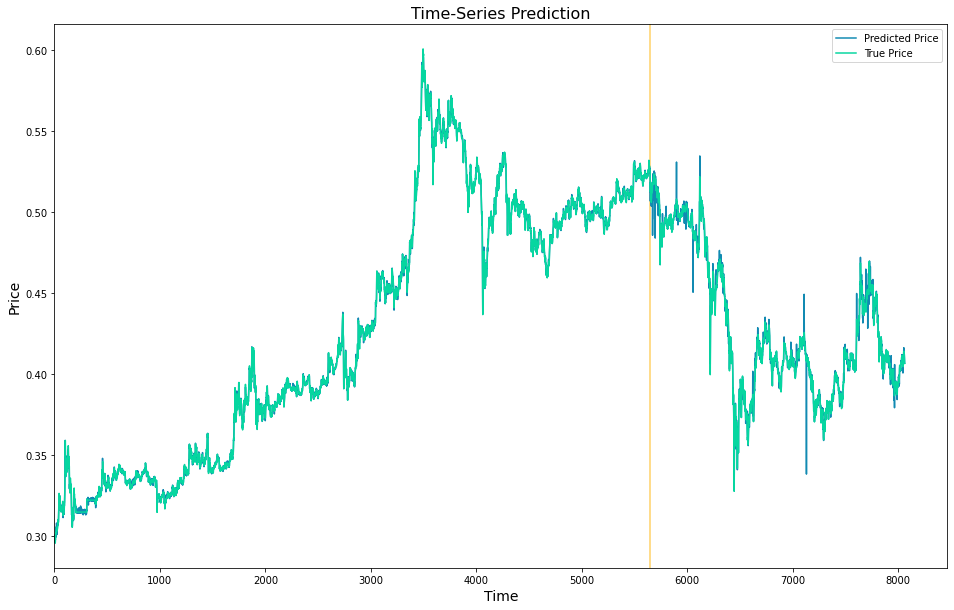

In [23]:
file_endings = ["5m.csv", "hourly.csv", "daily.csv"]

predictions = []
true = []

# FIXME: move to each fileending?
# im going to start with just 5m
file_ending = file_endings[0]
for filename in [name for name in file_list if file_ending in name]:
  crypto_name = filename.replace(file_ending, "")
  
  df = pd.read_csv(filename)
  # remove unused columns
  exclude_cols = [0,1,2,4]
  df = df.iloc[:, ~df.columns.isin(df.columns[exclude_cols])]

  # define LSTM class
  lstm = LSTMCustom(num_classes, input_size, hidden_size, num_layers, df.shape[1]) 
  optimizer = torch.optim.Adam(lstm.parameters(), lr=learning_rate) 

  lstm, cutoff = train(df, lstm)

  df_x_ss = ss.transform(df.iloc[:, 0:-1]) #old transformerso
  df_y_mm = mm.transform(df.iloc[:, 0:1]) #old transformers

  df_x_ss = Variable(torch.Tensor(df_x_ss)) #converting to Tensors
  df_y_mm = Variable(torch.Tensor(df_y_mm))
  #reshaping the dataset
  df_x_ss = torch.reshape(df_x_ss, (df_x_ss.shape[0], 1, df_x_ss.shape[1]))

  train_predict = lstm(df_x_ss) #forward pass
  data_predict = train_predict.data.numpy() #numpy conversion
  dataY_plot = df_y_mm.data.numpy()

  data_predict = mm.inverse_transform(data_predict) #reverse transformation
  dataY_plot = mm.inverse_transform(dataY_plot)

  predictions.append(data_predict)
  true.append(dataY_plot)

  plot_name = f"{crypto_name}.png"
  plot_time_series(data_predict, dataY_plot, cutoff, plot_name)

  model_name = f"{crypto_name}.pth"
  torch.save(lstm.state_dict(), model_name)

In [24]:
file_list = [f for f in listdir() if isfile(f)]

for filename in file_list:
  if ".csv" not in filename:
    files.download(filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>